In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')

# Store Item Demand Forecasting — Time Series Project

**Author:** Zakee Ul Hassan
**Dataset:** [Kaggle: Store Item Demand Forecasting](https://www.kaggle.com/competitions/demand-forecasting-kernels-only/data) — 913K rows of daily sales
**Goal:** Forecast next 3 months of daily sales across 50 items × 10 stores. Compare baseline, classical (ARIMA/SARIMA), and ML approaches with walk-forward validation.

In [40]:
df = pd.read_csv('../data/train.csv')
print("Shape:",df.shape)
df.head()


Shape: (913000, 4)


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [41]:
df['date'] = pd.to_datetime(df['date'])
print("Date column dtype:", df['date'].dtype)
print("Date range:", df['date'].min(), "→", df['date'].max())

Date column dtype: datetime64[ns]
Date range: 2013-01-01 00:00:00 → 2017-12-31 00:00:00


In [42]:
print("Total rows:", len(df))
print("Total days:", (df['date'].max() - df['date'].min()).days + 1)
print("Unique stores:", df['store'].nunique())
print("Unique items:", df['item'].nunique())
print("Total combinations:", df['store'].nunique() * df['item'].nunique())
print("Rows per store-item:", len(df) / (df['store'].nunique() * df['item'].nunique()))

Total rows: 913000
Total days: 1826
Unique stores: 10
Unique items: 50
Total combinations: 500
Rows per store-item: 1826.0


In [43]:
print("Sales summary statistics:")
print(df['sales'].describe())
print("\nMissing values:")
print(df.isnull().sum())

Sales summary statistics:
count    913000.000000
mean         52.250287
std          28.801144
min           0.000000
25%          30.000000
50%          47.000000
75%          70.000000
max         231.000000
Name: sales, dtype: float64

Missing values:
date     0
store    0
item     0
sales    0
dtype: int64


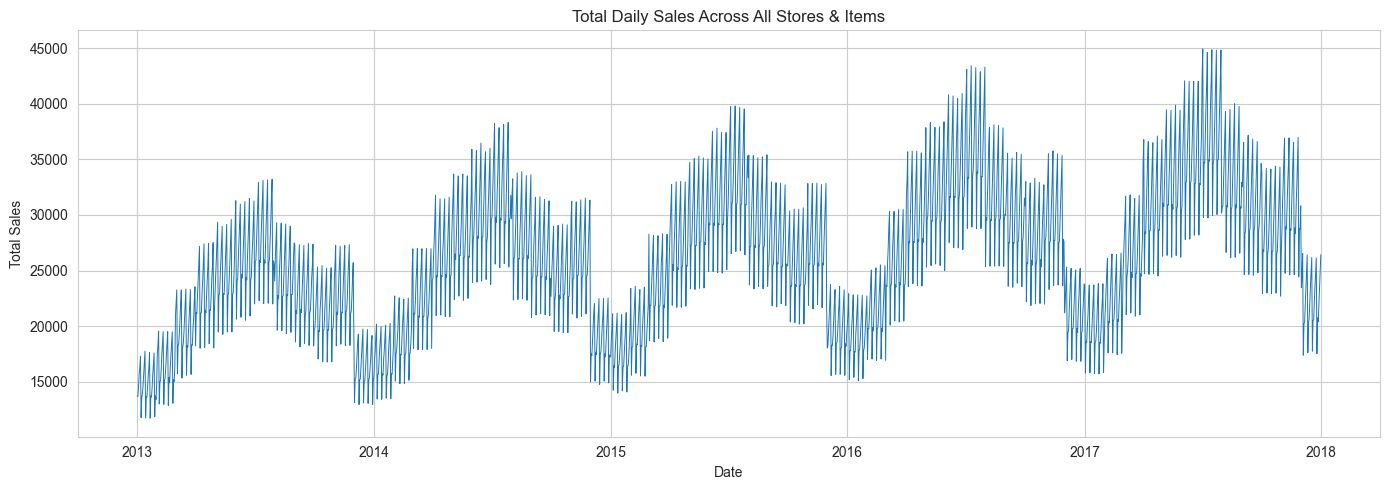

In [46]:
daily_total = df.groupby("date")["sales"].sum().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(daily_total['date'], daily_total['sales'], linewidth=0.7)
plt.title('Total Daily Sales Across All Stores & Items')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.savefig('../total_daily_sales.png', dpi=100, bbox_inches='tight')
plt.show()

In [47]:
daily_total.head()

,date,sales
0,2013-01-01,13696
1,2013-01-02,13678
2,2013-01-03,14488
3,2013-01-04,15677
4,2013-01-05,16237


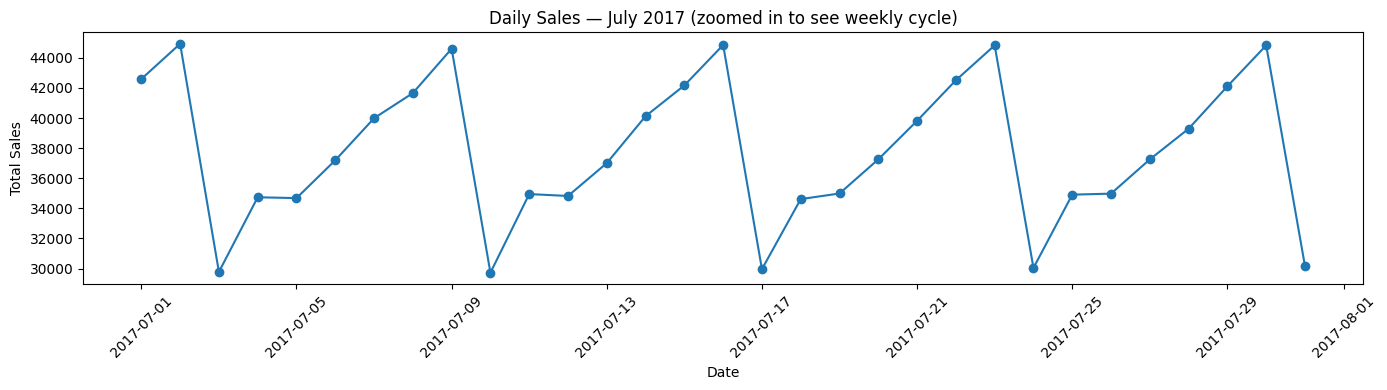

In [38]:
# Zoom in on one month to see weekly pattern
sample_month = daily_total[(daily_total['date'] >= '2017-07-01') & (daily_total['date'] <= '2017-07-31')]

plt.figure(figsize=(14, 4))
plt.plot(sample_month['date'], sample_month['sales'], marker='o', linewidth=1.5)
plt.title('Daily Sales — July 2017 (zoomed in to see weekly cycle)')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../weekly_cycle.png', dpi=100, bbox_inches='tight')
plt.show()

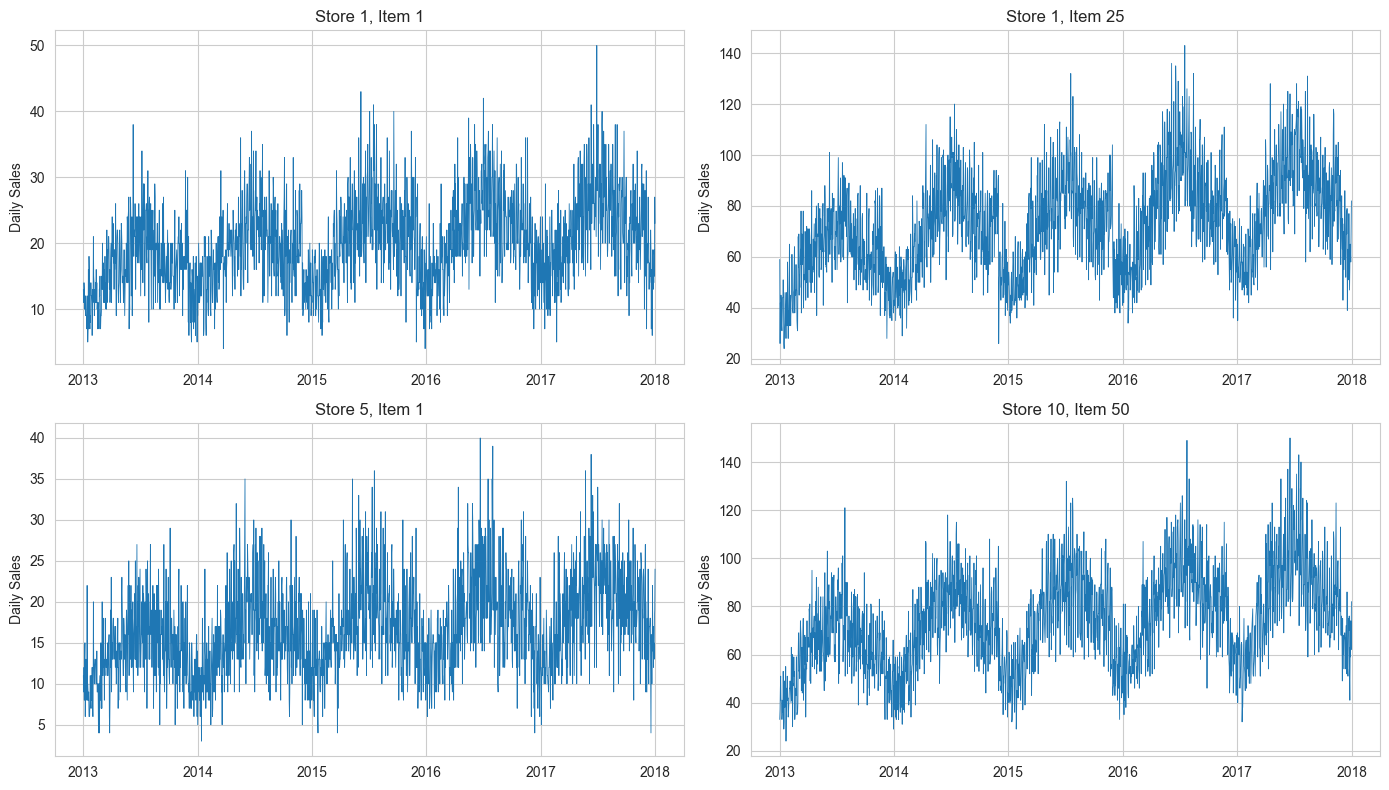

In [49]:
# Pick a few store-item combos to inspect individually
sample_combos = [
    (1, 1),    # store 1, item 1
    (1, 25),   # store 1, item 25 (mid-catalog)
    (5, 1),    # store 5, item 1 (different store, same item as first)
    (10, 50),  # store 10, item 50 (last store, last item)
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, (store, item) in enumerate(sample_combos):
    series = df[(df['store'] == store) & (df['item'] == item)]
    axes[i].plot(series['date'], series['sales'], linewidth=0.6)
    axes[i].set_title(f'Store {store}, Item {item}')
    axes[i].set_ylabel('Daily Sales')
    
plt.tight_layout()
plt.savefig('../sample_time_series.png', dpi=100, bbox_inches='tight')
plt.show()

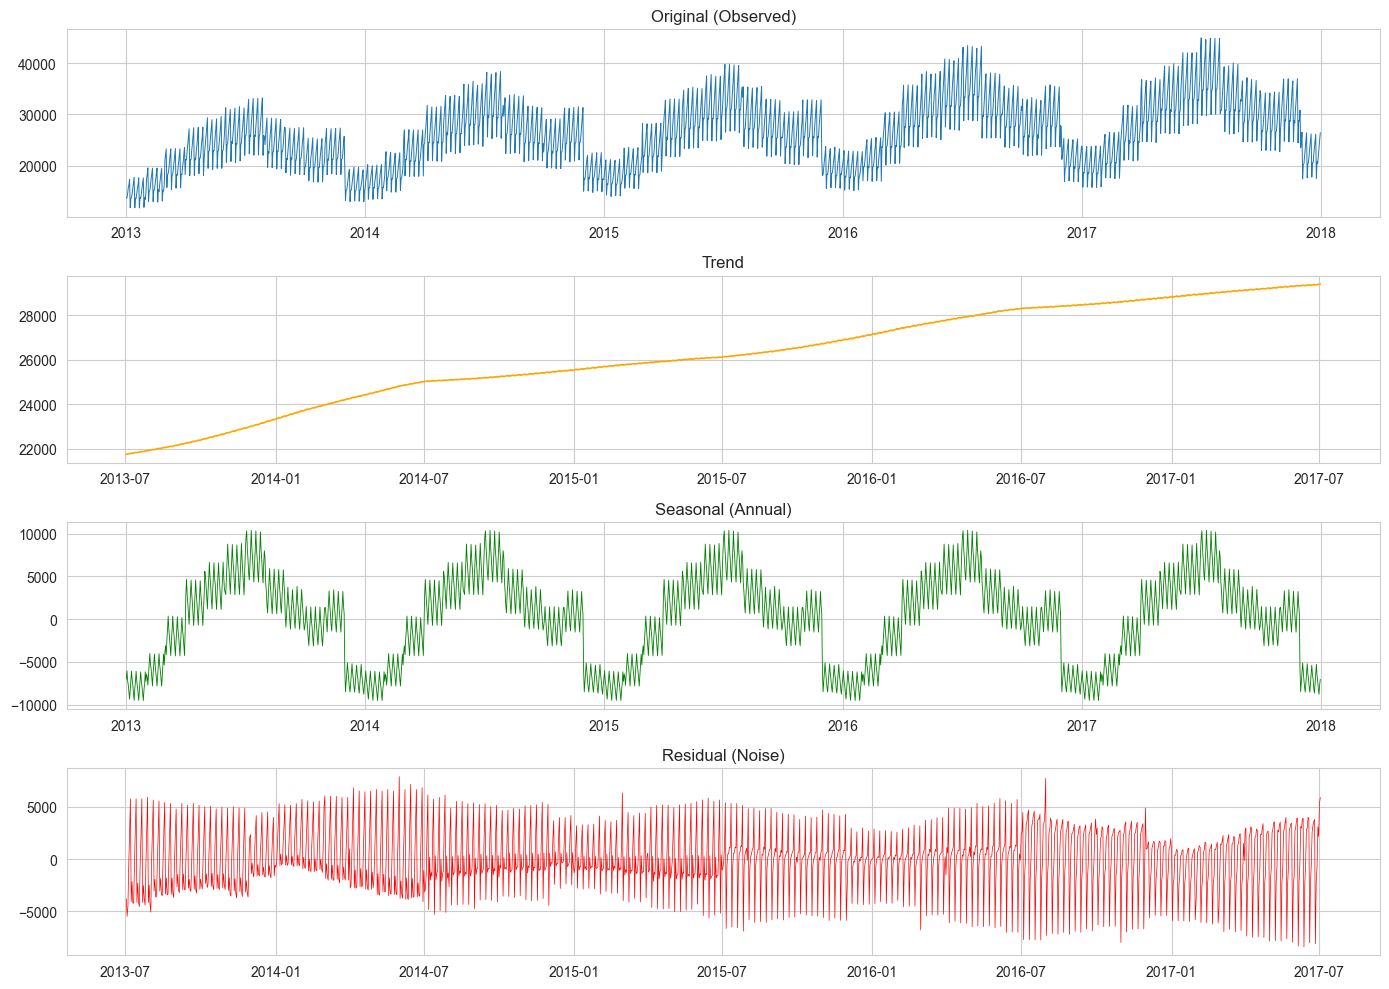

In [50]:
from statsmodels.tsa.seasonal import seasonal_decompose

# We need a clean time series with date as the index
ts = daily_total.set_index('date')['sales']

# Decompose with annual seasonality (period=365 days)
decomp = seasonal_decompose(ts, model='additive', period=365)

# Plot all 4 components: original, trend, seasonal, residual
fig, axes = plt.subplots(4, 1, figsize=(14, 10))

axes[0].plot(decomp.observed, linewidth=0.7)
axes[0].set_title('Original (Observed)')

axes[1].plot(decomp.trend, color='orange', linewidth=1.2)
axes[1].set_title('Trend')

axes[2].plot(decomp.seasonal, color='green', linewidth=0.6)
axes[2].set_title('Seasonal (Annual)')

axes[3].plot(decomp.resid, color='red', linewidth=0.5)
axes[3].set_title('Residual (Noise)')

plt.tight_layout()
plt.savefig('../decomposition.png', dpi=100, bbox_inches='tight')
plt.show()

### Initial Observations

- **Dataset:** 913,000 rows = 10 stores × 50 items × 1,826 days (5 years, 2013-2017). 500 distinct time series in total.
- **No missing values, no data quality issues** — clean dataset, can move directly to modeling pipeline.
- **Sales statistics:** range 0 to 231, mean ~52, integer-valued count data. Same family as my thesis target (mortality counts) — Poisson-like models will be appropriate.
- **Strong upward trend over 5 years** — sales are growing year-over-year; will need to handle non-stationarity before applying ARIMA.
- **Annual seasonality** with clear summer peaks (June-August). Suggests SARIMA with seasonal_period=365 or seasonal feature engineering.
- **Weekly cycle** visible in zoomed view — weekend peaks, weekday troughs. Will need to capture day-of-week in features for ML models.
- **Sample series are similar in shape, different in scale.** Inspected 4 store-item combos. All show same trend + seasonality + weekly pattern but at different magnitudes (peaks ~40 to ~140). This means a single model architecture should generalize across all 500 series — we won't need clustering or per-segment models.
- **Decomposition confirms 3 components:** clear upward trend, clean repeating annual seasonality, and residual showing weekly cycle (which annual decomposition didn't capture). Total demand has multi-scale seasonality — annual + weekly — both will need to be modeled.